In [46]:
import pandas as pd
import numpy as np

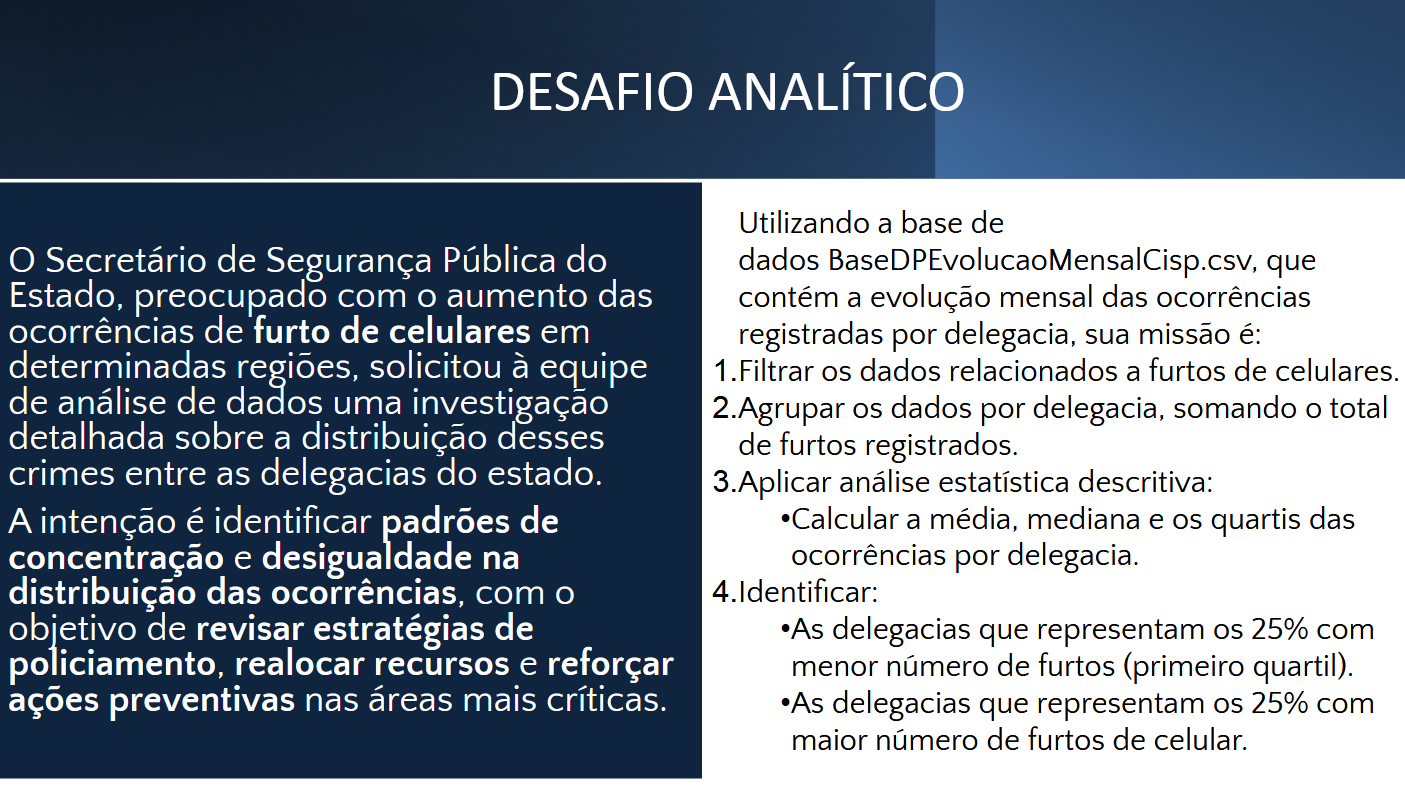

In [47]:
#importando dados
df = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv', sep=';')
df


,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36898,159,10,2025,2025m10,35,4,Cachoeiras de Macacu,3300803,Interior,1,...,4.0,0.0,37,2,0,0,0,0,163,2
36899,165,10,2025,2025m10,33,5,Mangaratiba,3302601,Interior,1,...,4.0,0.0,21,0,0,0,0,0,196,2
36900,166,10,2025,2025m10,33,5,Angra dos Reis,3300100,Interior,3,...,12.0,0.0,82,8,0,1,0,0,682,2
36901,167,10,2025,2025m10,43,5,Paraty,3303807,Interior,1,...,2.0,1.0,11,1,0,0,0,0,195,2


In [48]:
#reconhecendo colunas
df.columns

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [49]:
#Filtrando por furtos e transformando em float
df_furto = df.groupby('cisp')['furto_celular'].sum().reset_index()
df_furto['furto_celular'] = df_furto['furto_celular'].astype(float)

In [50]:
#Aplicando analise estatistica descritiva
array_furto_celular = np.array(df_furto['furto_celular'])

In [51]:
#Pegando medidas
media = np.mean(array_furto_celular)
mediana = np.median(array_furto_celular)
distancia = (media-mediana) / mediana
q1 = np.quantile(array_furto_celular, 0.25)
q2 = np.quantile(array_furto_celular, 0.5)
q3 = np.quantile(array_furto_celular, 0.75)


In [52]:
print(f'A média é {media}')
print(f'A mediana é {mediana}')
print(f'A distância é {distancia}')
print(f'Primeiro quartil (Q1): {q1}')
print(f'Segundo quartil (Q2, Mediana): {q2}')
print(f'Terceiro quartil (Q3): {q3}')

A média é 3338.1159420289855
A mediana é 1633.5
A distância é 1.0435359302289473
Primeiro quartil (Q1): 449.0
Segundo quartil (Q2, Mediana): 1633.5
Terceiro quartil (Q3): 4498.25


In [53]:
#Calculando os percentis
df_furto_menor_q1 = df_furto.loc[df_furto['furto_celular'] < q1]
df_furto_maior_q3 = df_furto.loc[df_furto['furto_celular'] > q3]
df_furto_menor_q1


,cisp,furto_celular
7,11,385.0
41,45,73.0
60,67,364.0
61,70,201.0
77,92,63.0
79,94,361.0
82,97,227.0
83,98,90.0
84,99,431.0
85,100,387.0


In [55]:
df_furto_menor_q1.to_csv('outlier_furto_celular.csv', sep=';', index=False)

In [ ]:
df_furto_maior_q3

,cisp,furto_celular
0,1,14968.0
1,4,13318.0
2,5,23117.0
3,6,6220.0
5,9,14159.0
6,10,14105.0
8,12,16008.0
9,13,7188.0
10,14,16945.0
11,15,6784.0


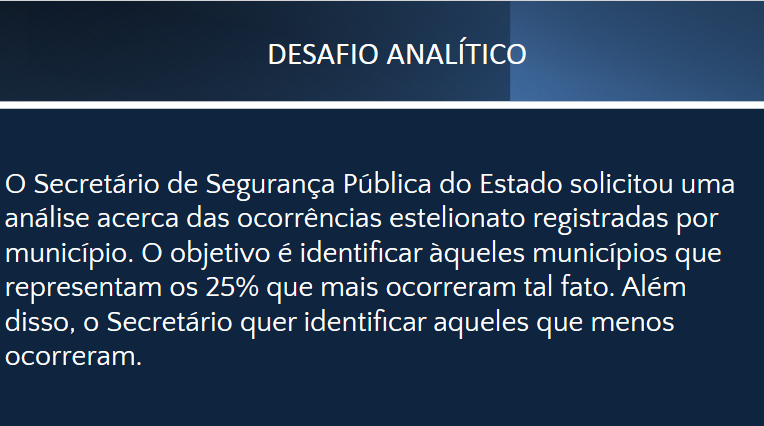

In [ ]:
#Filtrando DF por estelionato
df_estelionato = df.loc[(df['estelionato'])]
df_estelionato

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
69,91,1,2003,2003m01,10,5,Valença,3306107,Interior,0,...,NaN,NaN,28,2,1,0,0,0,177,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
37,44,1,2003,2003m01,3,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,18,1,0,0,0,0,464,3
8,13,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,26,1,0,0,0,0,455,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,30,1,2003,2003m01,9,2,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,90,2,4,0,0,0,577,3
32,37,1,2003,2003m01,17,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,84,7,9,0,0,0,745,3
134,13,2,2003,2003m02,19,1,Rio de Janeiro,3304557,Capital,1,...,NaN,NaN,28,2,1,0,0,0,387,3
27,32,1,2003,2003m01,18,2,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,181,9,3,0,0,0,830,3


In [ ]:
#Convertendo valores para float
df_estelionato['estelionato'] = df_estelionato['estelionato'].astype(float)

In [ ]:
#Agrupando estelionato por municipio
estelionato_munic = df.groupby('munic')['estelionato'].sum().reset_index()
estelionato_munic = estelionato_munic.sort_values(by='estelionato', ascending=False)
estelionato_munic

,munic,estelionato
68,Rio de Janeiro,606042
48,Niterói,50603
23,Duque de Caxias,41281
78,São Gonçalo,37222
50,Nova Iguaçu,36742
...,...,...
35,Laje do Muriaé,173
83,São Sebastião do Alto,138
61,Queimados;Japeri,50
57,Piraí;Pinheiral,8


In [ ]:
array_estelionato = np.array(estelionato_munic['estelionato'])

In [ ]:
#Fazendo medidas discritivas
media_estelionato = np.mean(array_estelionato)
mediana_estelionato = np.median(array_estelionato)
distancia_estelionato = (media_estelionato-mediana_estelionato) / mediana_estelionato
q1_estelionato = np.quantile(array_estelionato, 0.25)
q2_estelionato = np.quantile(array_estelionato, 0.50)
q3_estelionato = np.quantile(array_estelionato, 0.75)

In [ ]:
print(f'A média é {media_estelionato}')
print(f'A mediana é {mediana_estelionato}')
print(f'A distância é {distancia_estelionato}')
print(f'Primeiro quartil (Q1): {q1_estelionato}')
print(f'Segundo quartil (Q2, Mediana): {q2_estelionato}')
print(f'Terceiro quartil (Q3): {q3_estelionato}')

A média é 12167.655555555555
A mediana é 1472.0
A distância é 7.266070350241546
Primeiro quartil (Q1): 639.5
Segundo quartil (Q2, Mediana): 1472.0
Terceiro quartil (Q3): 7197.5


In [ ]:
#Encontrando municipio com mais estelionato
munic_mais_estelionato = estelionato_munic.loc[estelionato_munic['estelionato'] > q3_estelionato]
munic_mais_estelionato

,munic,estelionato
68,Rio de Janeiro,606042
48,Niterói,50603
23,Duque de Caxias,41281
78,São Gonçalo,37222
50,Nova Iguaçu,36742
81,São João de Meriti,23172
13,Campos dos Goytacazes,22142
54,Petrópolis,17251
36,Macaé,16577
89,Volta Redonda,16050


In [ ]:
#Encontrando municipio com menos estelionato
munic_menos_estelionato = estelionato_munic.loc[estelionato_munic['estelionato'] < q1_estelionato]
munic_menos_estelionato
df['aaapai'] = df['aaapai'].astype(float)

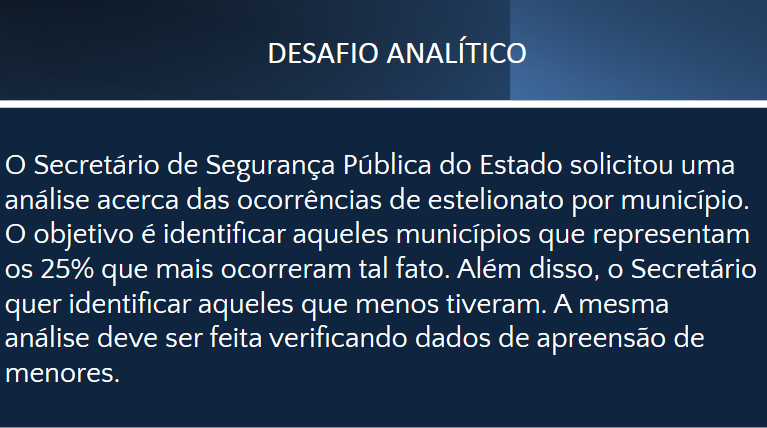

In [ ]:
apreensao_munic = df.groupby('munic')['aaapai'].sum().reset_index()
apreensao_munic = apreensao_munic.sort_values(by='aaapai', ascending=True)
apreensao_munic


,munic,aaapai
14,Campos dos Goytacazes;São Francisco de Itabapoana,0.0
57,Piraí;Pinheiral,0.0
61,Queimados;Japeri,0.0
66,Rio das Flores,12.0
75,Sumidouro,13.0
...,...,...
48,Niterói,5316.0
13,Campos dos Goytacazes,5468.0
23,Duque de Caxias,6244.0
78,São Gonçalo,7176.0


In [ ]:
array_apreesao = np.array(apreensao_munic['aaapai'])

In [ ]:
#Fazendo medidas discritivas
media_apreesao = np.mean(array_apreesao)
mediana_apreesao = np.median(array_apreesao)
distancia_apreesao = (media_apreesao-mediana_apreesao) / mediana_apreesao
q1_apreesao = np.quantile(array_apreesao, 0.25)
q2_apreesao = np.quantile(array_apreesao, 0.50)
q3_apreesao = np.quantile(array_apreesao, 0.75)
iqr = q3 - q1
limite_s= q3 + 1.5*iqr
limite_i = q1 - 1.5*iqr

In [ ]:
# print
print(f'A média é {media_apreesao}')
print(f'A mediana é {mediana_apreesao}')
print(f'Primeiro quartil (Q1): {q1_apreesao}')
print(f'Segundo quartil (Q2, Mediana): {q2_apreesao}')
print(f'Terceiro quartil (Q3): {q3_apreesao}')
print(f"O limite superior é {limite_s}")
print(f'O limite inferior é {limite_i}')

A média é 1353.2444444444445
A mediana é 297.5
Primeiro quartil (Q1): 86.0
Segundo quartil (Q2, Mediana): 297.5
Terceiro quartil (Q3): 934.25
O limite superior é 10572.125
O limite inferior é -5624.875


In [ ]:
outlier_furto_celular = df_furto.loc[df_furto['furto_celular'] > limite_s]
outlier_furto_celular


,cisp,furto_celular
0,1,14968.0
1,4,13318.0
2,5,23117.0
5,9,14159.0
6,10,14105.0
8,12,16008.0
10,14,16945.0
12,16,24879.0
14,18,12939.0
28,32,12206.0


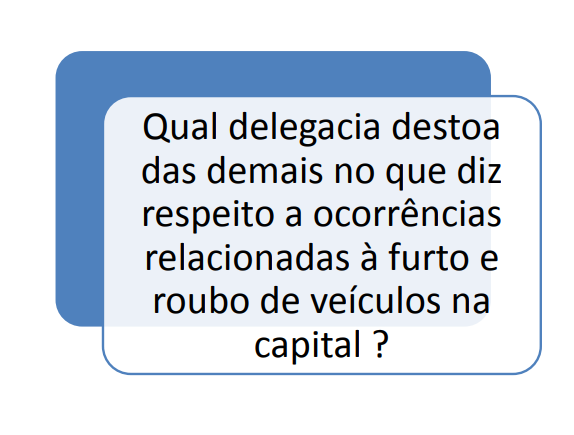

In [ ]:
# roubo_veiculo e furto_veículo
df[['furto_veiculos','roubo_veiculo']] = df[['furto_veiculos','roubo_veiculo']].astype(float)
df['furto_roubo'] = df['furto_veiculos'] + df['roubo_veiculo']
df_furto_roubo = df.groupby('cisp')['furto_roubo'].sum().reset_index()
df_furto_roubo

,cisp,furto_roubo
0,1,2494.0
1,4,3402.0
2,5,4343.0
3,6,6777.0
4,7,3941.0
...,...,...
133,159,715.0
134,165,2375.0
135,166,3017.0
136,167,678.0


In [ ]:
#criando array
array_furto_roubo = np.array(df_furto_roubo['furto_roubo'])

In [ ]:
# Calculando estatística
media_furto_roubo = np.mean(array_furto_roubo)
mediana_furto_roubo = np.median(array_furto_roubo)
q1_furto_roubo = np.percentile(array_furto_roubo, 0.25)
q2_furto_roubo = np.percentile(array_furto_roubo, 0.5)
q3_furto_roubo = np.percentile(array_furto_roubo, 0.75)
distancia_furto_roubo = (media_furto_roubo + mediana_furto_roubo)/mediana_furto_roubo
iqr_furto_roubo = q3_furto_roubo - q1_furto_roubo
limite_s_furto_roubo = q3 + 1.5*iqr_furto_roubo
limite_i_furto_roubo = q1 + 1.5*iqr_furto_roubo


In [ ]:
# print estatística
print(f'A média é {media_furto_roubo}')
print(f'A mediana é {mediana_furto_roubo}')
print(f'Primeiro quartil (Q1): {q1_furto_roubo}')
print(f'Segundo quartil (Q2, Mediana): {q2_furto_roubo}')
print(f'Terceiro quartil (Q3): {q3_furto_roubo}')
print(f"O limite superior é {limite_s_furto_roubo}")
print(f'O limite inferior é {limite_i_furto_roubo}')


A média é 8052.572463768116
A mediana é 3086.5
Primeiro quartil (Q1): 23.37
Segundo quartil (Q2, Mediana): 24.740000000000002
Terceiro quartil (Q3): 26.989999999999995
O limite superior é 4503.68
O limite inferior é 454.43


In [ ]:
# Encontrando delegacias outliers
outlier_s_furto_roubo = df_furto_roubo.loc[df_furto_roubo['furto_roubo'] > limite_s_furto_roubo]
outlier_f_furto_roubo = df_furto_roubo.loc[df_furto_roubo['furto_roubo'] < limite_i_furto_roubo]

# Mostrando delegacias superiores
print('As delegacias superiores são:')
outlier_s_furto_roubo


As delegacias superiores são:


,cisp,furto_roubo
3,6,6777.0
5,9,12705.0
6,10,9669.0
12,16,18151.0
13,17,11250.0
14,18,11239.0
15,19,10180.0
16,20,13238.0
17,21,25267.0
18,22,22896.0


In [ ]:
# Mostrando delegacias inferiores
print('As delegacias inferiores são:')
outlier_f_furto_roubo

As delegacias inferiores são:


,cisp,furto_roubo
7,11,181.0
41,45,78.0
76,91,446.0
77,92,22.0
79,94,346.0
82,97,169.0
83,98,89.0
84,99,292.0
85,100,317.0
86,101,168.0


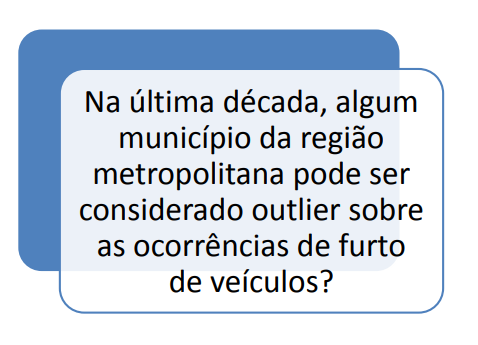

In [ ]:
# Criando consulta para caso de furto de veículos em municípios

df_furto_munic = df.groupby('munic')['furto_veiculos'].sum().reset_index()
df_furto_munic

,munic,furto_veiculos
0,Angra dos Reis,2049.0
1,Araruama,2838.0
2,Armação dos Búzios,1122.0
3,Arraial do Cabo,340.0
4,Barra Mansa,2179.0
...,...,...
85,Teresópolis,2481.0
86,Trajano de Morais,47.0
87,Valença,397.0
88,Vassouras,377.0


In [ ]:
# Criando array

array_furto_munic = np.array(df_furto_munic['furto_veiculos'])

# Calculando estatísticas

q1_furto_veiculos = np.percentile(array_furto_munic, 0.25)
q3_furto_veiculos = np.percentile(array_furto_munic, 0.75)
iqr = q3_furto_veiculos - q1_furto_veiculos
limite_s_furto_veiculos = q3_furto_veiculos + (1.5*iqr)
limite_i_furto_veiculos = q1_furto_veiculos - (1.5*iqr)

# Procurando outliers

outlier_furto_munic = df_furto_munic.loc[(df_furto_munic['furto_veiculos'] > limite_s_furto_roubo) | (df_furto_munic['furto_veiculos'] < limite_i_furto_veiculos)]

# Mostrando municipios

outlier_furto_munic = outlier_furto_munic.sort_values(by='furto_veiculos', ascending=False).reset_index()
outlier_furto_munic

,index,munic,furto_veiculos
0,68,Rio de Janeiro,194327.0
1,48,Niterói,26305.0
2,78,São Gonçalo,24711.0
3,23,Duque de Caxias,23202.0
4,50,Nova Iguaçu,20527.0
5,81,São João de Meriti,11463.0
6,13,Campos dos Goytacazes,7872.0
7,6,Belford Roxo,7693.0
8,89,Volta Redonda,5570.0
9,47,Nilópolis,4989.0


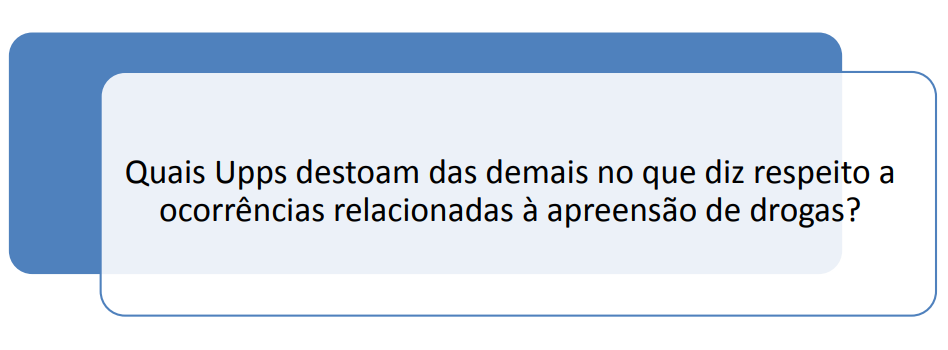

In [ ]:
# Importando dataframe

df_upp = pd.read_csv('https://www.ispdados.rj.gov.br/Arquivos/UppEvolucaoMensalDeTitulos.csv', sep=';', encoding="iso-8859-1")
df_upp.columns

Index(['cod_upp', 'upp', 'ano', 'mes', 'hom_doloso', 'lesao_corp_morte',
       'latrocinio', 'hom_por_interv_policial', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_comercio', 'roubo_residencia', 'roubo_veiculo', 'roubo_carga',
       'roubo_transeunte', 'roubo_em_coletivo', 'roubo_banco',
       'roubo_cx_eletronico', 'roubo_celular', 'roubo_conducao_saque',
       'total_roubos', 'furto_veiculos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'recuperacao_veiculos', 'armas_apreendidas', 'cump_mandado_prisao',
       'ocorr_flagrante', 'ameaca', 'pessoas_desaparecidas',
       'encontro_cadaver', 'encontro_ossada', 'pol_militares_mortos_serv',
       'pol_civis_mortos_serv', 'registro_ocorrencias'],
      dtype='object')

In [ ]:
# Identificando upps e apreensões
df_upp['apreensao_drogas'] = df_upp['apreensao_drogas'].astype(float)
df_drogas_upp = df_upp.groupby('upp')['apreensao_drogas'].sum().reset_index()
df_drogas_upp

,upp,apreensao_drogas
0,Adeus / Baiana,295.0
1,Alemão,257.0
2,Andaraí,389.0
3,Arará / Mandela,598.0
4,Barreira do Vasco / Tuiuti,627.0
5,Batam,310.0
6,Borel,555.0
7,Caju,275.0
8,Camarista Méier,245.0
9,Cerro-Corá,122.0


In [ ]:
# Criando array

array_drogas_upp = np.array(df_drogas_upp['apreensao_drogas'])

# Criando estatisticas

q1_drogas_upp = np.quantile(array_drogas_upp, 0.25)
q3_drogas_upp = np.quantile(array_drogas_upp, 0.75)
iqr_drogas_upp = q3_drogas_upp - q1_drogas_upp
limite_s_drogas_upp = q3_drogas_upp + 1.5*iqr_drogas_upp
limite_i_drogas_upp = q1_drogas_upp - 1.5*iqr_drogas_upp

# Demonstrando as com apreensoes acima do limite superior

outlier_s_droga_upp = df_drogas_upp.loc[df_drogas_upp['apreensao_drogas'] > limite_s_drogas_upp]
outlier_s_droga_upp

,upp,apreensao_drogas
12,Cidade de Deus,2818.0
18,Jacarezinho,1132.0
37,Vila Kennedy,1363.0


In [ ]:
# Demonstrando as com apreensoes abaixo do limite inferior

outlier_i_droga_upp = df_drogas_upp.loc[df_drogas_upp['apreensao_drogas'] < limite_i_drogas_upp]
outlier_i_droga_upp

,upp,apreensao_drogas


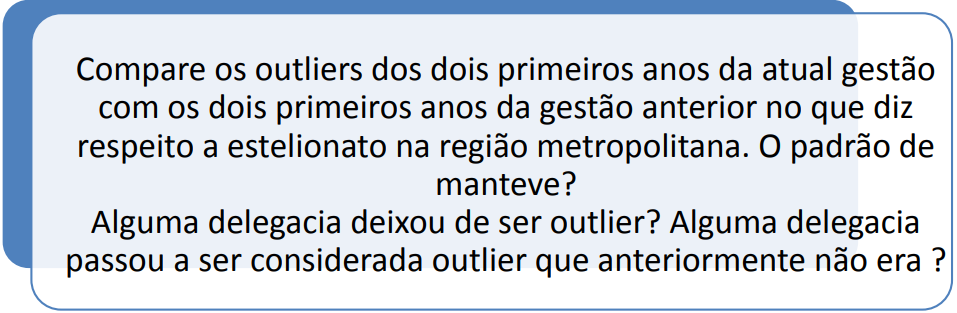

In [ ]:
#Criando DF somente da Região metropolitana
munic_metropolina = ['Rio de Janeiro','Belford Roxo','Cachoeiras de Macacu','Duque de Caxias','Guapimirim','Itaboraí','Itaboraí','Itaguaí','Japeri','Magé','Maricá','Nilópolis','Niterói','Nova Iguaçu','Paracambi','Queimados','Rio Bonito','Seropédica','São Gonçalo','São João de Meriti','Tanguá']
df_metropolitana = df.loc[df['munic'].isin(munic_metropolina)]
df_metropolitana

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,furto_roubo
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,21,2,0,0,0,0,578,3,17.0
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,15,6,0,1,0,0,441,3,18.0
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,47,2,1,0,0,0,637,3,39.0
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,26,2,1,0,0,0,473,3,44.0
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,10,1,3,0,0,0,147,3,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36835,79,10,2025,2025m10,12,4,Niterói,3303302,Grande Niterói,1,...,0.0,19,3,0,0,0,0,309,2,10.0
36836,81,10,2025,2025m10,12,4,Niterói,3303302,Grande Niterói,2,...,1.0,29,3,0,0,0,0,410,2,4.0
36837,82,10,2025,2025m10,12,4,Maricá,3302700,Grande Niterói,2,...,0.0,107,8,0,2,0,0,981,2,12.0
36862,119,10,2025,2025m10,35,4,Rio Bonito,3304300,Interior,2,...,1.0,15,3,1,0,0,0,231,2,8.0


In [ ]:
#Gestão atual (ano: 2023 e 2024)
#Criando tabela
df_gestao_atual = df_metropolitana.loc[(df_metropolitana['ano'] == 2023) | (df_metropolitana['ano'] == 2024)]

#Criando array
array_metropolitana_atual = np.array(df_gestao_atual['estelionato'])

#Criando estatística

q1_metropolitana_atual = np.quantile(array_metropolitana_atual, 0.25)
q3_metropolitana_atual = np.quantile(array_metropolitana_atual, 0.75)
iqr_metropolitana_atual = q3_metropolitana_atual - q1_metropolitana_atual
limite_s_atual= q3_metropolitana_atual + 1.5*iqr_metropolitana_atual
limite_i_atual = q1_metropolitana_atual - 1.5*iqr_metropolitana_atual
limite_i_atual

#display outliers (outlier inferior < 0, logo não há)

outlier_gestao_atual = df_gestao_atual.loc[df_gestao_atual['estelionato'] > q3_metropolitana_atual]
outlier_gestao_atual

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,furto_roubo
32250,9,1,2023,2023m01,2,1,Rio de Janeiro,3304557,Capital,0,...,0.0,26,4,0,0,0,0,1013,3,29.0
32253,12,1,2023,2023m01,19,1,Rio de Janeiro,3304557,Capital,2,...,6.0,38,9,0,0,0,0,1534,3,15.0
32255,14,1,2023,2023m01,23,1,Rio de Janeiro,3304557,Capital,0,...,4.0,16,12,0,0,0,0,971,3,28.0
32257,16,1,2023,2023m01,31,2,Rio de Janeiro,3304557,Capital,2,...,5.0,71,5,0,0,0,0,1871,3,67.0
32260,19,1,2023,2023m01,6,1,Rio de Janeiro,3304557,Capital,1,...,0.0,33,7,2,0,0,0,822,3,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35442,54,12,2024,2024m12,39,3,Belford Roxo,3300456,Baixada Fluminense,19,...,1.0,106,23,0,0,0,0,1617,3,215.0
35447,59,12,2024,2024m12,15,3,Duque de Caxias,3301702,Baixada Fluminense,6,...,1.0,103,14,0,3,0,0,1912,3,217.0
35458,72,12,2024,2024m12,7,4,São Gonçalo,3304904,Grande NiterÃÂ³i,2,...,0.0,57,6,0,0,0,0,994,3,100.0
35463,77,12,2024,2024m12,12,4,Niterói,3303302,Grande NiterÃÂ³i,0,...,1.0,35,0,1,0,0,0,797,3,10.0


In [ ]:
#Criando outliers gestão anterior (ano: 2019 e 2020)
df_gestao_antiga = df_metropolitana.loc[(df_metropolitana['ano'] == 2019) | (df_metropolitana['ano'] == 2020)]

#Criando array
array_metropolitana_antiga = np.array(df_gestao_atual['estelionato'])

#Criando estatística

q1_metropolitana_antiga = np.quantile(array_metropolitana_antiga, 0.25)
q3_metropolitana_antiga = np.quantile(array_metropolitana_antiga, 0.75)
iqr_metropolitana_antiga = q3_metropolitana_antiga - q1_metropolitana_antiga
limite_s_antiga= q3_metropolitana_antiga + 1.5*iqr_metropolitana_antiga
limite_i_antiga = q1_metropolitana_antiga - 1.5*iqr_metropolitana_antiga

#display outliers

outlier_gestao_antiga = df_gestao_antiga.loc[df_gestao_antiga['estelionato'] > q3_metropolitana_antiga]
outlier_gestao_antiga

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,furto_roubo
26522,35,7,2019,2019m07,40,2,Rio de Janeiro,3304557,Capital,5,...,2.0,133,15,1,1,0,0,1581,3,199.0
26902,1,10,2019,2019m10,5,1,Rio de Janeiro,3304557,Capital,0,...,2.0,15,1,0,0,0,0,701,3,2.0
26933,35,10,2019,2019m10,40,2,Rio de Janeiro,3304557,Capital,3,...,5.0,181,8,0,0,0,0,1564,3,148.0
27039,1,11,2019,2019m11,5,1,Rio de Janeiro,3304557,Capital,0,...,2.0,18,2,0,0,0,0,1043,3,4.0
27176,1,12,2019,2019m12,5,1,Rio de Janeiro,3304557,Capital,1,...,1.0,9,0,1,0,0,0,770,3,5.0
27450,1,2,2020,2020m02,5,1,Rio de Janeiro,3304557,Capital,0,...,3.0,15,2,0,0,0,0,906,3,4.0
27889,32,5,2020,2020m05,18,2,Rio de Janeiro,3304557,Capital,6,...,1.0,88,6,0,0,0,0,941,3,29.0
28010,16,6,2020,2020m06,31,2,Rio de Janeiro,3304557,Capital,2,...,1.0,35,6,0,0,0,0,937,3,13.0
28026,32,6,2020,2020m06,18,2,Rio de Janeiro,3304557,Capital,1,...,0.0,96,5,0,0,0,0,1101,3,25.0
28029,35,6,2020,2020m06,40,2,Rio de Janeiro,3304557,Capital,4,...,0.0,55,7,0,1,0,0,1010,3,131.0


O padrão de estelionato aumentou esse ano em relação ao ano anterior.

In [ ]:
# Alguma delegacia deixou de ser outlier?

lista_outliers_deixou = outlier_gestao_atual['cisp'].unique()
delegacias_deixaram = outlier_gestao_antiga[~outlier_gestao_antiga['cisp'].isin(lista_outliers_deixou)]
delegacias_deixaram_unicas = delegacias_deixaram.drop_duplicates(subset=['cisp'])
delegacias_deixaram_unicas[['cisp','ano']]

,cisp,ano
26902,1,2019


In [ ]:
# Alguma delegacia passou a ser outlier?

lista_outliers_passaram = outlier_gestao_antiga['cisp'].unique()
delegacias_passaram = outlier_gestao_atual[outlier_gestao_atual['cisp'].isin(lista_outliers_passaram)]
delegacias_passaram_unicas = delegacias_passaram.drop_duplicates(subset=['cisp'])
delegacias_passaram_unicas[['cisp','ano']]

,cisp,ano
32257,16,2023
32273,32,2023
32275,34,2023
32276,35,2023
32301,64,2023
32825,36,2023


In [ ]:
# Inicio da aula dia 03/12
import matplotlib.pyplot as plt


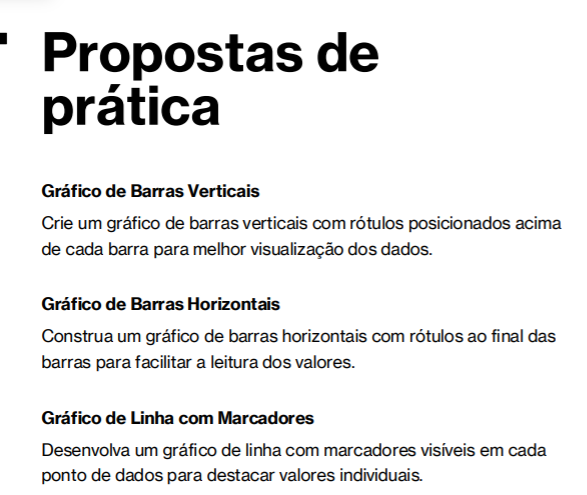

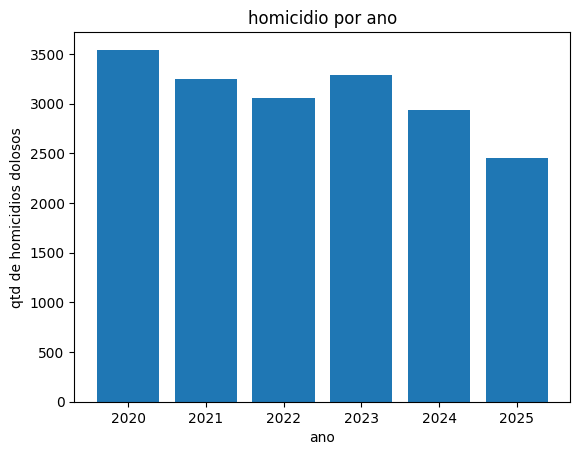

In [ ]:
# grafico de barras v - (homicido doloso por ano desde 2020)

df_2020_2025 = df.loc[df['ano'] > 2019]
df_2020_2025_agrupado = df_2020_2025.groupby('ano')['hom_doloso'].sum().reset_index()
plt.bar(df_2020_2025_agrupado['ano'] , df_2020_2025_agrupado['hom_doloso'])
plt.title('homicidio por ano')
plt.xlabel('ano')
plt.ylabel('qtd de homicidios dolosos')
plt.show()





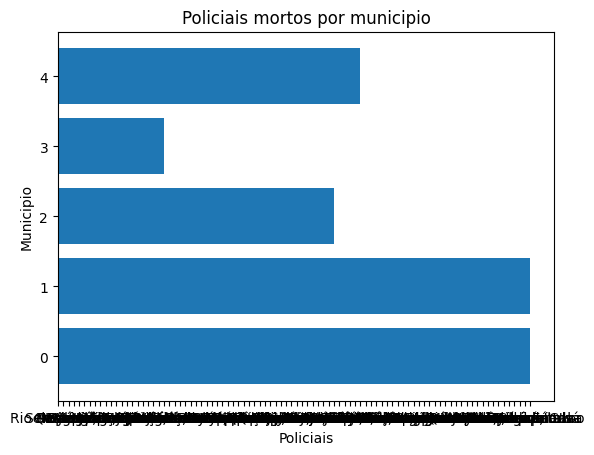

In [ ]:
# grafico de barras h - (policiais mortos em serviço por municipio) pol_militares_mortos_serv
plt.barh(df['pol_militares_mortos_serv'],df['munic'])
plt.title('Policiais mortos por municipio')
plt.xlabel('Policiais')
plt.ylabel('Municipio')
plt.show()

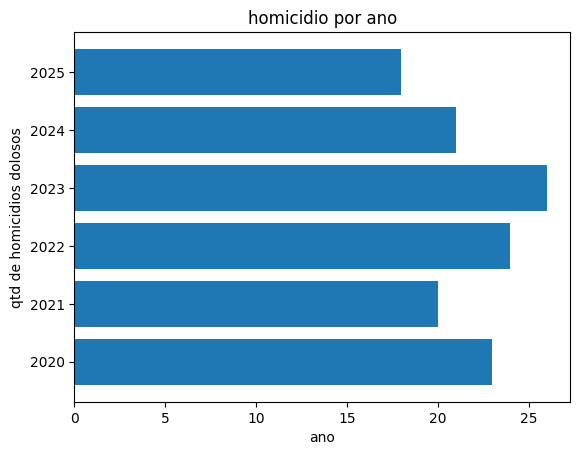

In [ ]:
# grafico de linhas - (ano x hom_doloso )
df_2020_2025 = df.loc[df['ano'] > 2019]
plt.barh(df_2020_2025['ano'] , df_2020_2025['hom_doloso'])
plt.title('homicidio por ano')
plt.xlabel('ano')
plt.ylabel('qtd de homicidios dolosos')
plt.show()